In [1]:
# build large-scale data in scBank format from a group of AnnData objects
# %%
import gc
import json
from pathlib import Path
import argparse
import shutil
import traceback
from typing import Dict, List, Optional
import warnings
import numpy as np
import os
import anndata

import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from typing import Any, Dict, List, Mapping, Optional, Tuple, Union
from typing_extensions import Self, Literal
from scipy.sparse import issparse

import matplotlib as mpl
def set_vis_default(font = 1.6, circle_marker = 1.):
    mpl.rcParams['font.family'] = 'Arial'
    plt.rcParams.update(plt.rcParamsDefault)
#     %matplotlib inline
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        plt.style.use('seaborn-v0_8-whitegrid')

    sns.set_context('paper',font_scale=font)
    plt.rcParams["legend.markerscale"] = circle_marker
    mpl.rcParams['font.family'] = 'Arial'



In [10]:
base_path = '/import/home2/xwanaf/Img2Expr/data/Reproducibility_data/PF'
file_path = Path(base_path) / 'sp_map_to_sc_Epi'

file_name = 'UGE_sp_EpiAll.h5ad'
adata_sp = sc.read(file_path / file_name)
adata_sp

/home/xwanaf/.conda/envs/scGPT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 177178 × 1741
    obs: 'sample', 'patient', 'cell_id', 'sample_type', 'sample_affect', 'disease_status', 'percent_pathology', 'tma', 'run', 'final_CT', 'final_lineage', 'CNiche', 'TNiche', 'lumen_id', 'lumen_rank', 'x_centroid', 'y_centroid', 'adj_x_centroid', 'adj_y_centroid', 'super_adj_x_centroid', 'super_adj_y_centroid', 'nCount_RNA', 'nFeature_RNA', 'perc_negcontrolprobe', 'perc_negcontrolcodeword', 'perc_unassigned', 'perc_negcontrolorunassigned', 'n_genes', 'pred_atlas', 'predict_mapped_ct_anno_prob', 'Slides'

In [23]:
adata_sp.obs.index = [f'{i}_{j}' for i,j in zip(adata_sp.obs.index, adata_sp.obs['sample'])]

In [24]:
base_path = '/import/home2/xwanaf/Img2Expr/data/Reproducibility_data/PF'
file_path = Path(base_path) / 'sp_map_to_sc_Epi'

file_name = 'Raw_sp_EpiAll.h5ad'
adata_sp_raw = sc.read(file_path / file_name)
adata_sp_raw = adata_sp_raw[adata_sp.obs.index]

# Merge with spatial neighbor cell type composition

Please run ./spatial_nrb_src/get_nrb_prop.py first to get ./spatial_nrb_src/output/prop_adata_diseases.h5ad

In [34]:
prop_adata = sc.read('./spatial_nrb_src/output/prop_adata_diseases.h5ad')

In [35]:
prop_df = adata_sp.obs.merge(prop_adata.to_df(), left_index = True, right_index = True)

In [36]:
prop_df.head()

,sample,patient,cell_id,sample_type,sample_affect,disease_status,percent_pathology,tma,run,final_CT,...,Plasmacytoid DCs,Mesothelial,Migratory DCs,Alveolar Mph CCL3+,Ionocyte,Secretory MUC5B+,Alveolar Mph proliferating,Suprabasal SCGB1A1+,DC1,Neuroendocrine
aaaaabnk-1_VUILD91LA,VUILD91LA,VUILD91,aaaaabnk-1,LF,Less Affected,Disease,15,TMA4,Run2,Basal,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
aaaaadka-1_VUILD91LA,VUILD91LA,VUILD91,aaaaadka-1,LF,Less Affected,Disease,15,TMA4,Run2,Multiciliated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
aaaaadke-1_VUILD91LA,VUILD91LA,VUILD91,aaaaadke-1,LF,Less Affected,Disease,15,TMA4,Run2,Basal,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
aaaaadkf-1_VUILD91LA,VUILD91LA,VUILD91,aaaaadkf-1,LF,Less Affected,Disease,15,TMA4,Run2,Multiciliated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
aaaaadkg-1_VUILD91LA,VUILD91LA,VUILD91,aaaaadkg-1,LF,Less Affected,Disease,15,TMA4,Run2,Multiciliated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
adata_sp_raw = adata_sp_raw[prop_df.index]
adata_sp_raw.obs = prop_df
adata_sp_raw

AnnData object with n_obs × n_vars = 151375 × 343
    obs: 'sample', 'patient', 'cell_id', 'sample_type', 'sample_affect', 'disease_status', 'percent_pathology', 'tma', 'run', 'final_CT', 'final_lineage', 'CNiche', 'TNiche', 'lumen_id', 'lumen_rank', 'x_centroid', 'y_centroid', 'adj_x_centroid', 'adj_y_centroid', 'super_adj_x_centroid', 'super_adj_y_centroid', 'nCount_RNA', 'nFeature_RNA', 'perc_negcontrolprobe', 'perc_negcontrolcodeword', 'perc_unassigned', 'perc_negcontrolorunassigned', 'n_genes', 'pred_atlas', 'predict_mapped_ct_anno_prob', 'Slides', 'Monocyte-derived Mph', 'EC venous systemic', 'FB ECM SOX4+', 'CD4 T cells', 'FB ECM', 'Plasma cells', 'EC general capillary', 'AT2', 'myo-FB', 'Pericytes', 'CD8 T cells', 'Ciliated', 'SMCs', 'FB COL1A1+', 'SCGB3A1+/SCGB3A2+', 'FB HAS1+', 'B cells', 'Basal', 'EC arterial', 'Aberrant Basaloid', 'AT1', 'Mast cells', 'Alveolar macrophages', 'Interstitial Mph perivascular', 'DC2', 'Lymphatic EC mature', 'FB ECM CHI3L2+', 'Classical monocyte

## select SCGB3A1+/SCGB3A2+ as center cell type and investigate its expression change along the increase of neighboring AT2 composition

In [38]:
center_cts = [''SCGB3A1+/SCGB3A2+, 'SCGB1A1+/SCGB3A1+/SCGB3A2+']
nrb_ct = 'AT2'
adata_sl = adata_sp_raw[adata_sp_raw.obs['pred_atlas'].isin(center_cts)].copy()
adata_sl = adata_sl[adata_sl.obs.sort_values(nrb_ct).index]

In [31]:
import colormaps as cmaps

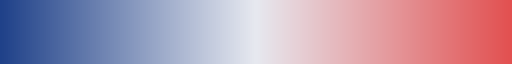

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap


cmap_color_list = ['#2D5FA5'] + ['#EEBE49'] * 12 + ['#C93226'] * 20 #F4DB5D 7F7F7F
cmap_color_list = ['#2a2a63', '#3f539e', '#dad854', '#F5EB54']
# cmap_color_list = ['#81C0DD', '#DBC3DC', 'white', '#FEF251', '#C93226'] #5860A7 2D5FA5, 158ECE
cmap_color_list = ['#1f4189', '#e7e9f0', '#e25050']

cmap_gene = LinearSegmentedColormap.from_list('custom_cmap', cmap_color_list)
cmap_gene

/tmp/ipykernel_3453698/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/tmp/ipykernel_3453698/1719159811.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Spectral').reversed()


(5083, 5)


/tmp/ipykernel_3453698/1719159811.py:109: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm.ScalarMappable(norm=norm, cmap=cm.get_cmap('Spectral').reversed()),


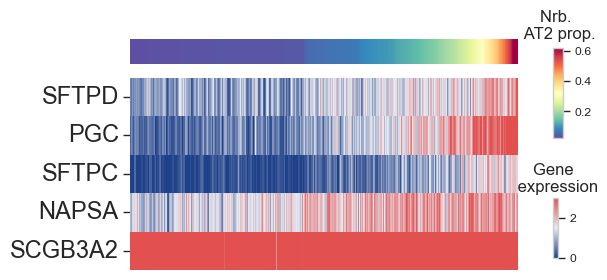

In [45]:
from matplotlib.patches import Patch
from matplotlib import cm

def dendrogram_reorder_df(df_sub, return_index = False):
    clustermap_sub = sns.clustermap(
        df_sub.values,
        figsize = (5, 3),
        row_cluster=False, 
        col_cluster=True,
    #     col_colors = col_colors
    )
    reorder_index = clustermap_sub.dendrogram_col.reordered_ind
#     clustermap_sub.ax_heatmap.set_yticklabels(clustermap_sub.ax_heatmap.get_ymajorticklabels(), rotation=0)
    # plt.show()
    plt.close()
    df_sub = df_sub.iloc[:, reorder_index]
    return df_sub
    


set_vis_default(font = 1.)


gene_set_reorder = [[
    'SFTPD', 'PGC', 'SFTPC', 'NAPSA',
    'SCGB3A2'
]]
gene_names_reorder = ['selected']

ratio = [len(_) for _ in gene_set_reorder]
ratio[0] = ratio[0] * 1.2
gene_len = sum(ratio)

fig, axs = plt.subplots(1, 1, figsize=(5, 3), gridspec_kw={'wspace': .04, 'hspace': 0.1})

for i, (gene_set_name, gene_set) in enumerate(zip(gene_names_reorder, gene_set_reorder)):
    adata_sub = adata_sl[:, gene_set].copy() # cell x gene
    index = adata_sub.obs[nrb_ct] > 0
    adata_sub = adata_sub[index]
    
    window_size = 20
    arr_all = np.array(adata_sub.X).squeeze()
    smoothed_expression = [pd.Series(arr).rolling(window=window_size, center=True).mean() for arr in arr_all.T]
    smoothed_expression = np.column_stack(smoothed_expression)
    notnan_index = np.where(np.isnan(smoothed_expression) == False)[0]
    slice_start, slice_end = notnan_index.min(), notnan_index.max()
    smoothed_expression = smoothed_expression[slice_start:slice_end, :]
    df_vis = pd.DataFrame(
        smoothed_expression, 
#         index = adata_sub.obs.index,
        columns = gene_set
    )
    
    mtx_df = df_vis.iloc[:, ::-1]
#     mtx_df = dendrogram_reorder_df(df_vis) # cell x gene
    print(mtx_df.shape)
    
    ax = axs#[i]
    
    group_col = [gene_set_name] * mtx_df.shape[1]
    group_df = pd.DataFrame(group_col, index = adata_sub.var_names, columns = ['group'])

    cmap = cm.get_cmap('Spectral').reversed() 
    float_values = adata_sub.obs[nrb_ct] 
    smoothed_expression = pd.Series(float_values).rolling(window=window_size, center=True).mean() 
    smoothed_expression = smoothed_expression.values.squeeze()
    float_values = smoothed_expression[slice_start:slice_end]
    
    norm = plt.Normalize(vmin=np.quantile(float_values, .01), vmax=np.quantile(float_values, .99))

    col_colors = cmap(norm(float_values))

    sns.heatmap( #sns.heatmap clustermap
        mtx_df.T,
        cmap = cmap_gene,
        vmax = 3,
#         vmin = 0, vmax = 4., center = 1.,
#         row_colors = row_colors,
#         col_colors = col_colors,
#         row_cluster=False, 
#         col_cluster=False,
        cbar = False,
        ax = ax
    )
    
    ax.tick_params(axis='y', labelsize=17)  # Set the desired font size

    
    if i == 0:
        for j, color in enumerate(col_colors):
            ax.axvline(
                x=j - 0.5, 
                ymin = .9,
                color=color, 
                linewidth=2
            )  # Draw vertical lines for column colors
        ax.set_ylim([0, mtx_df.shape[1] + 1])
        
    

    ax.set_xticks([])
    ax.set_xticklabels([])
    
    
### cbar of nrb. prop
cbar_ax = fig.add_axes([0.97, 0.55, 0.02, 0.3])  # [left, bottom, width, height]

cbar = plt.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cm.get_cmap('Spectral').reversed()),
    shrink=0.1,
    pad = .2, cax=cbar_ax
)  # Create a colorbar

cbar.set_label(f'', fontsize=12)  # Set the label for the colorbar
cbar.ax.text(
    0.5, 1.1, 
    f'Nrb. \n AT2 prop.', 
    ha='center', 
#     va='center', 
    fontsize=12, 
#     fontweight='bold', 
    transform=cbar.ax.transAxes
)
### cbar of gene expression
cbar_ax = fig.add_axes([0.97, 0.15, 0.01, 0.2])  # [left, bottom, width, height]

cbar = plt.colorbar(
    cm.ScalarMappable(norm=plt.Normalize(vmin=0, vmax=3), cmap=cmap_gene),
    shrink=0.1,
    pad = .2, cax=cbar_ax
)  # Create a colorbar

cbar.set_label(f'', fontsize=12)  # Set the label for the colorbar
cbar.ax.text(
    0.5, 1.1, 
    f'Gene \n expression', 
    ha='center', 
#     va='center', 
    fontsize=12, 
#     fontweight='bold', 
    transform=cbar.ax.transAxes
)


    
# plt.savefig(
#     f'./save_figs/spatial/DE_genes_along_nrb_prop_centerSCGB_nrbAT2.png', 
#     format='png', dpi = 200, bbox_inches='tight',pad_inches=.2
# )
plt.show()
plt.close()

